Assuming a stock follows GBM:
$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

Then the price $V(S,t)$ of a european derivative satisfies the Black--Scholes equation:
$$
\frac{\partial V}{\partial t}
+\frac{1}{2}\sigma^{2} S^{2} \frac{\partial^{2} V}{\partial S^{2}}
+r S \frac{\partial V}{\partial S}
- r V = 0,
\qquad
V(S,T)=\max(S-K,0).
$$

Intuition (what each term is doing):

$$
\frac{\partial V}{\partial t}
\quad\text{: time is passing, so the option value changes even if } S \text{ stays the same (time decay).}
$$

$$
\frac{1}{2}\sigma^{2} S^{2} \frac{\partial^{2} V}{\partial S^{2}}
\quad\text{: diffusion / uncertainty term. Larger } \sigma \text{ means more spreading. }
\frac{\partial^{2}V}{\partial S^{2}} \text{ (gamma) measures curvature, and curvature is what gets ``smoothed'' like heat.}
$$

$$
r S \frac{\partial V}{\partial S}
\quad\text{: comes from hedging with } \Delta=\frac{\partial V}{\partial S} \text{ shares of stock and the fact that cash grows at rate } r.
$$

$$
- r V
\quad\text{: discounting / time value of money. A value that is paid in the future must be consistent with earning the risk-free rate } r.
$$

$$
V(S,T)=\max(S-K,0)
\quad\text{: the terminal payoff at expiration for a call (the kink that gets smoothed for } t<T\text{).}
$$

Closed-form solution (european call):
$$
V(S,t)=S\,N(d_1)-K e^{-r(T-t)}N(d_2),
$$
$$
d_1=\frac{\ln(S/K)+\left(r+\frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}},
\qquad
d_2=d_1-\sigma\sqrt{T-t},
$$
$$
N(\cdot)\ \text{is the CDF of a standard normal random variable.}
$$


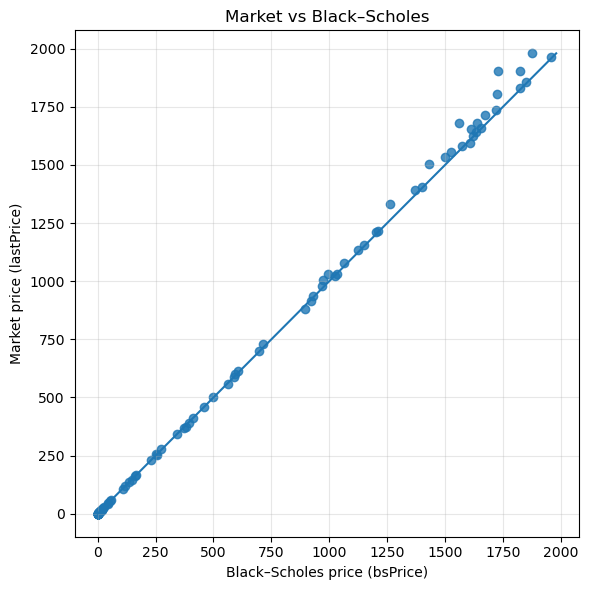

In [84]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from bsutils.funcs import blackScholes, build_bs_param_df

df = pd.read_csv("../data/spx_options_synthetic_100.csv")

df["bsPrice"] = df.apply(
    lambda row: blackScholes(row["r"], row["S"], row["K"], row["T"], row["sigma"], row["type"]),
    axis=1
)

# lastPrice vs bsPrice
plt.figure(figsize=(6,6))
plt.scatter(df["bsPrice"], df["lastPrice"], alpha=0.8)

mn = float(min(df["bsPrice"].min(), df["lastPrice"].min()))
mx = float(max(df["bsPrice"].max(), df["lastPrice"].max()))
plt.plot([mn, mx], [mn, mx])  # 45° line

plt.xlabel("Black–Scholes price (bsPrice)")
plt.ylabel("Market price (lastPrice)")
plt.title("Market vs Black–Scholes")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
